In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [2]:
df = pd.read_csv("data/Social_Media_Advertising.csv")

In [3]:
df

,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,$500.00,5.790000,Las Vegas,Spanish,500,3000,7,Health,2022-02-25,Aura Align
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,$500.00,7.210000,Los Angeles,French,500,3000,5,Home,2022-05-12,Hearth Harmony
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,$500.00,0.430000,Austin,Spanish,500,3000,9,Technology,2022-06-19,Cyber Circuit
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,$500.00,0.909824,Miami,Spanish,293,1937,1,Health,2022-09-08,Well Wish
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,$500.00,1.422828,Austin,French,293,1937,1,Home,2022-08-24,Hearth Harmony
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,565525,Men 25-34,Market Expansion,60 Days,Instagram,0.14,$15000.00,4.950000,Los Angeles,English,39999,119998,7,Technology,2022-10-17,Code Crafters
299996,539680,Women 25-34,Market Expansion,60 Days,Instagram,0.08,$15000.00,3.410000,Austin,Spanish,39999,119998,8,Technology,2022-02-25,Innovate Infinity
299997,140032,Women 35-44,Brand Awareness,60 Days,Pinterest,0.09,$15000.00,0.904461,Miami,French,23492,77476,1,Food,2022-10-02,Gastronomy Guild
299998,161067,Women 18-24,Market Expansion,60 Days,Instagram,0.13,$15000.00,7.430000,Las Vegas,Spanish,39999,119999,10,Food,2022-01-24,Savor Street


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       300000 non-null  int64  
 1   Target_Audience   300000 non-null  object 
 2   Campaign_Goal     300000 non-null  object 
 3   Duration          300000 non-null  object 
 4   Channel_Used      300000 non-null  object 
 5   Conversion_Rate   300000 non-null  float64
 6   Acquisition_Cost  300000 non-null  object 
 7   ROI               300000 non-null  float64
 8   Location          300000 non-null  object 
 9   Language          300000 non-null  object 
 10  Clicks            300000 non-null  int64  
 11  Impressions       300000 non-null  int64  
 12  Engagement_Score  300000 non-null  int64  
 13  Customer_Segment  300000 non-null  object 
 14  Date              300000 non-null  object 
 15  Company           300000 non-null  object 
dtypes: float64(2), int64

In [5]:
df.shape

(300000, 16)

In [6]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,550444.804487,0.080009,3.177691,18153.670370,56034.236387,4.369217
std,260252.586037,0.040563,2.461200,11027.023294,32583.136334,3.156492
min,100001.000000,0.010000,0.000000,293.000000,1937.000000,1.000000
25%,325003.500000,0.050000,0.930000,8821.000000,28362.000000,1.000000
50%,551164.500000,0.080000,2.670000,17230.000000,54098.000000,4.000000
75%,776284.500000,0.110000,5.330000,26808.000000,80925.250000,7.000000
max,999998.000000,0.150000,8.000000,40000.000000,120000.000000,10.000000


In [7]:
df.isnull()

,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
299996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
299997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
299998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum().sum()

0

In [11]:
df['Acquisition_Cost'].unique()[:10]

array(['$500.00', '$500.10', '$500.18', '$500.20', '$500.27', '$500.45',
       '$500.49', '$500.59', '$500.61', '$500.66'], dtype=object)

In [12]:
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace('$','')
df['Acquisition_Cost'] = df['Acquisition_Cost'].astype(float)

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [15]:
df.drop('Date', axis=1, inplace=True)

In [16]:
df.isnull().sum()

Campaign_ID         0
Target_Audience     0
Campaign_Goal       0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Company             0
Year                0
Month               0
Day                 0
dtype: int64

In [17]:
df = df.dropna()

In [18]:
df.cov(numeric_only=True)

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score,Year,Month,Day
Campaign_ID,6.773141e+10,-8.028774,3.752297e+06,310.476673,8.342850e+06,2.537627e+07,1546.821723,0.0,-3702.457196,-2159.052210
Conversion_Rate,-8.028774e+00,0.001645,3.621771e-01,-0.000025,9.149637e-01,2.714239e+00,-0.000255,0.0,-0.000002,-0.000286
Acquisition_Cost,3.752297e+06,0.362177,1.849890e+07,-17.559880,4.390926e+07,1.322011e+08,-37.093338,0.0,-50.385243,105.546547
ROI,3.104767e+02,-0.000025,-1.755988e+01,6.057507,5.111572e+03,1.331288e+04,2.755712,0.0,0.010203,-0.007885
Clicks,8.342850e+06,0.914964,4.390926e+07,5111.571665,1.215952e+08,3.588526e+08,6964.658477,0.0,-75.365680,199.742542
Impressions,2.537627e+07,2.714239,1.322011e+08,13312.876124,3.588526e+08,1.061661e+09,18127.385540,0.0,-244.268804,624.280609
Engagement_Score,1.546822e+03,-0.000255,-3.709334e+01,2.755712,6.964658e+03,1.812739e+04,9.963442,0.0,0.011373,-0.060062
Year,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000
Month,-3.702457e+03,-0.000002,-5.038524e+01,0.010203,-7.536568e+01,-2.442688e+02,0.011373,0.0,11.891709,0.213071
Day,-2.159052e+03,-0.000286,1.055465e+02,-0.007885,1.997425e+02,6.242806e+02,-0.060062,0.0,0.213071,77.425692


In [19]:
df['Success'] = np.where(df['ROI'] > 3, 1, 0)

In [20]:
X = df.drop('Success', axis=1)
Y = df['Success']

In [21]:
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

In [22]:
df.drop('Campaign_ID', axis=1, inplace=True)

In [23]:
df['Success'] = np.where(df['ROI'] > 3, 1, 0)

In [24]:
X = df.drop('Success', axis=1)
Y = df['Success']

In [25]:
X = pd.get_dummies(X, drop_first=True)

In [26]:
X.dtypes

Conversion_Rate           float64
Acquisition_Cost          float64
ROI                       float64
Clicks                      int64
Impressions                 int64
                           ...   
Company_Vigor Valley         bool
Company_Vital Vigor          bool
Company_Vogue Visions        bool
Company_Well Wish            bool
Company_Wellness Waves       bool
Length: 85, dtype: object

In [29]:
xtrain, xtest, ytrain, ytest = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [30]:
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [31]:
logreg = LogisticRegression()
logreg.fit(xtrain, ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
y_pred = logreg.predict(xtest)
y_train_pred = logreg.predict(xtrain)

In [33]:
cm = confusion_matrix(ytest, y_pred)
print(cm)

[[31779     9]
 [   18 28194]]


In [34]:
accuracy_score(ytest, y_pred)

0.99955

In [35]:
precision_score(ytest, y_pred)

0.9996808850122327

In [36]:
recall_score(ytest, y_pred)

0.9993619736282433

In [37]:
print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
print("Accuracy:", accuracy_score(ytest, y_pred))
print("Precision:", precision_score(ytest, y_pred))
print("Recall:", recall_score(ytest, y_pred))

Confusion Matrix:
 [[31779     9]
 [   18 28194]]
Accuracy: 0.99955
Precision: 0.9996808850122327
Recall: 0.9993619736282433


In [38]:
error_rate = 1 - accuracy_score(ytest, y_pred)
print("Error Rate:", error_rate)

Error Rate: 0.00044999999999995044


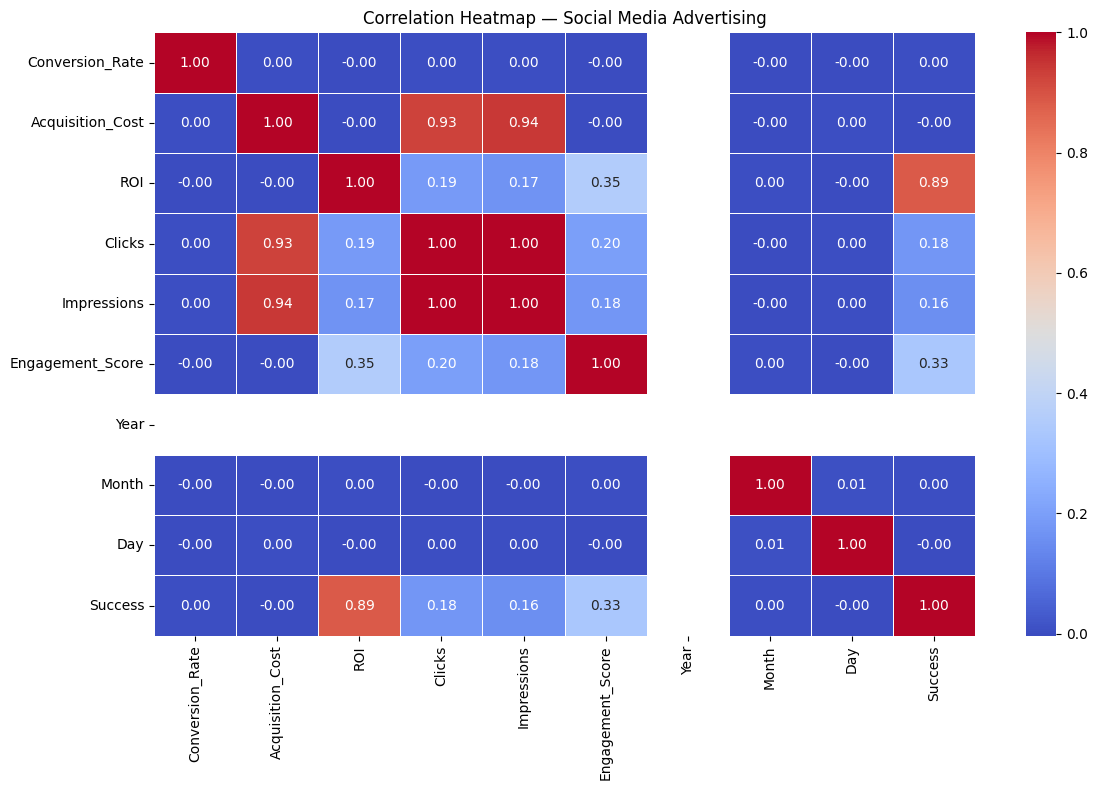

In [42]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f",
            cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Social Media Advertising")
plt.tight_layout()
plt.show()

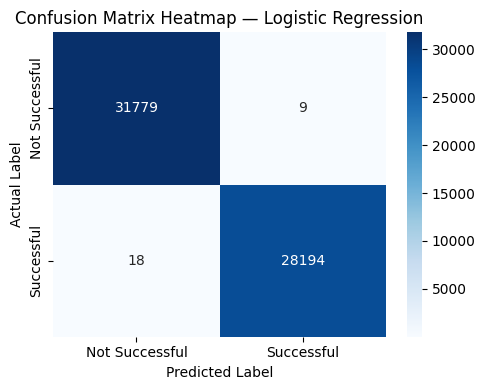

In [43]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap — Logistic Regression")
plt.tight_layout()
plt.show()

In [44]:
TN, FP, FN, TP = cm.ravel()
print(f"TP : {TP}")
print(f"TN : {TN}")
print(f"FP : {FP}")
print(f"FN : {FN}")
print(f"Accuracy   : {accuracy_score(ytest, y_pred):.4f}")
print(f"Error Rate : {1 - accuracy_score(ytest, y_pred):.4f}")
print(f"Precision  : {precision_score(ytest, y_pred):.4f}")
print(f"Recall     : {recall_score(ytest, y_pred):.4f}")

TP : 28194
TN : 31779
FP : 9
FN : 18
Accuracy   : 0.9996
Error Rate : 0.0004
Precision  : 0.9997
Recall     : 0.9994
